# 🎨 Denoising Diffusion Probabilistic Model (DDPM) on CIFAR-10

## Lab Assignment — Media Generation via Deep Learning Models

**Model:** Diffusion Model (DDPM)  
**Dataset:** CIFAR-10 (32×32 color images, 10 classes)  
**Goal:** Train a diffusion model from scratch to generate new images by learning to reverse a gradual noising process.

---

## 📖 Theoretical Background

### What is a Diffusion Model?

Diffusion models are a class of generative models inspired by non-equilibrium thermodynamics. They work in **two phases**:

1. **Forward Process (Diffusion):** Gradually add Gaussian noise to an image over `T` timesteps until it becomes pure noise.  
2. **Reverse Process (Denoising):** Train a neural network to predict and remove the noise at each step, effectively learning to generate images from pure noise.

### Forward Process

Given a data point $x_0$, we define a Markov chain that adds Gaussian noise:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t \mathbf{I})$$

where $\beta_t$ is a variance schedule. A convenient closed form allows sampling $x_t$ directly from $x_0$:

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$.

### Reverse Process

We train a U-Net $\epsilon_\theta(x_t, t)$ to predict the noise $\epsilon$ added at each step. The training objective is:

$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

### Architecture: U-Net with Time Embeddings

The denoising network is a U-Net with:
- **Sinusoidal time embeddings** to condition on the timestep
- **Residual blocks** for stable training
- **Skip connections** between encoder and decoder
- **Self-attention** in deeper layers

---

## 1. Setup & Imports

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

import numpy as np
import matplotlib.pyplot as plt
import math
import os
from tqdm.auto import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 2. Hyperparameters & Configuration

In [26]:
# ── Diffusion Hyperparameters ──────────────────────────────────────────────────
T            = 1000       # Total diffusion timesteps
BETA_START   = 1e-4       # Starting noise variance (small, image nearly clean)
BETA_END     = 0.02       # Ending noise variance (image nearly pure noise)

# ── Training Hyperparameters ───────────────────────────────────────────────────
IMAGE_SIZE   = 32         # CIFAR-10 native resolution
CHANNELS     = 3          # RGB images
BATCH_SIZE   = 128        # Batch size (reduce to 64 if running on CPU)
EPOCHS       = 2        # Epochs (increase to 200+ for best quality)
LR           = 2e-4       # Learning rate
NUM_WORKERS  = 2

# ── U-Net Architecture ────────────────────────────────────────────────────────
MODEL_DIM    = 64         # Base channel dimension
DIM_MULTS    = (1, 2, 4)  # Channel multipliers per resolution level

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_DIR     = './outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('Configuration set.')
print(f'  Timesteps T     : {T}')
print(f'  Beta range      : {BETA_START} → {BETA_END}')
print(f'  Image size      : {IMAGE_SIZE}×{IMAGE_SIZE}×{CHANNELS}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Training epochs : {EPOCHS}')

Configuration set.
  Timesteps T     : 1000
  Beta range      : 0.0001 → 0.02
  Image size      : 32×32×3
  Batch size      : 128
  Training epochs : 2


## 3. Dataset — CIFAR-10

Training samples : 50,000
Batches per epoch: 391


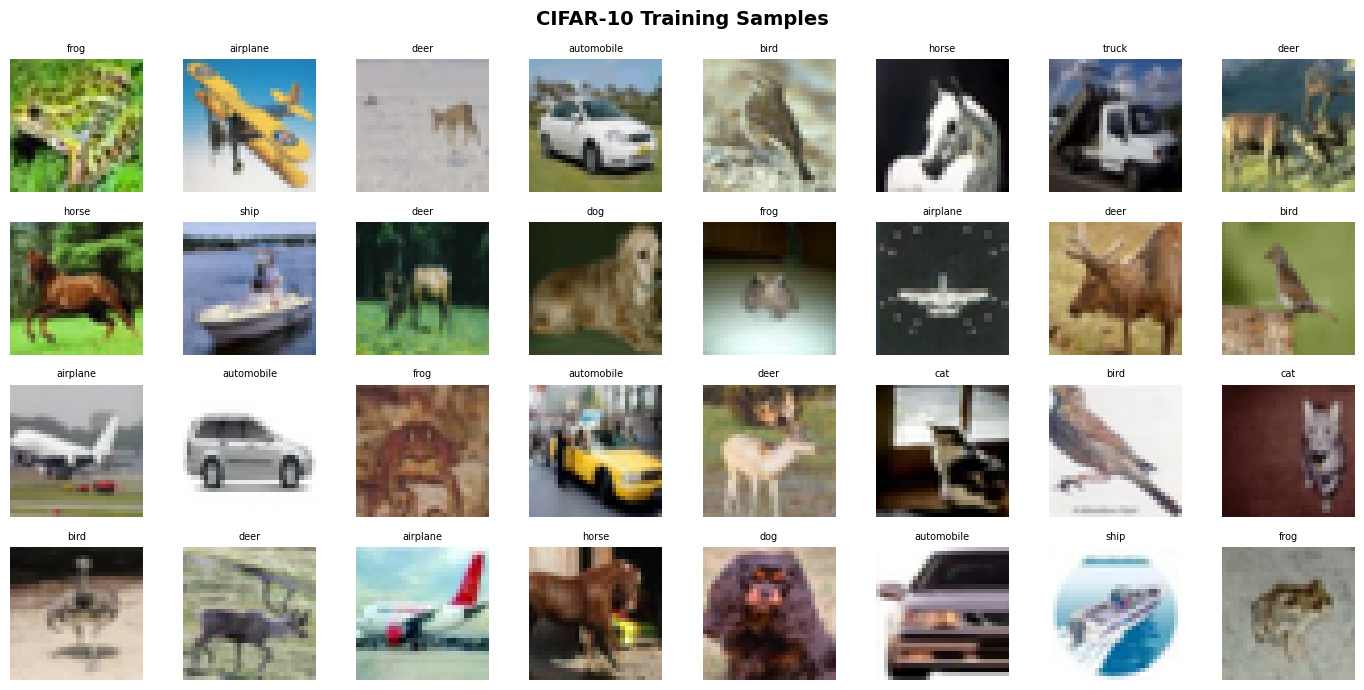

In [27]:
# ── Data Transforms ───────────────────────────────────────────────────────────
# Normalize to [-1, 1] — matches what the diffusion model expects
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # light augmentation
    transforms.ToTensor(),                       # [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))        # → [-1, 1]
])

train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Training samples : {len(train_dataset):,}')
print(f'Batches per epoch: {len(train_loader)}')

# ── Visualise a batch ─────────────────────────────────────────────────────────
def denormalize(t):
    """Convert [-1,1] tensor back to [0,1] for display."""
    return (t * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for ax, img, lbl in zip(axes.flat, images[:32], labels[:32]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-10 Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cifar10_samples.png', dpi=120)
plt.show()

## 4. Noise Schedule — β, α, ᾱ

We use a **linear beta schedule**: $\beta_t$ increases linearly from `BETA_START` to `BETA_END`.  
All derived quantities ($\alpha_t$, $\bar{\alpha}_t$, $\sqrt{\bar{\alpha}_t}$, etc.) are pre-computed and cached for efficiency.

Noise schedule initialised.


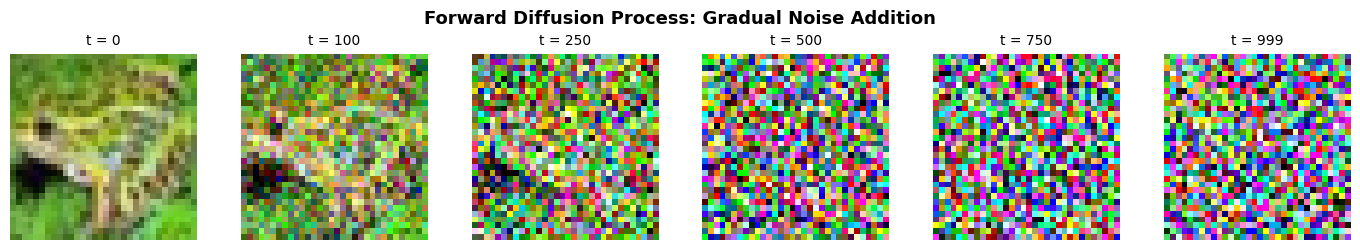

In [28]:
class NoiseSchedule:
    """
    Pre-computes and stores all quantities derived from the linear beta schedule.
    All tensors are moved to `device` for fast indexing during training.
    """
    def __init__(self, T, beta_start, beta_end, device):
        self.T = T

        # β_1 … β_T — linear schedule
        betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

        alphas           = 1.0 - betas
        alphas_cumprod   = torch.cumprod(alphas, dim=0)          # ᾱ_t
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)  # ᾱ_{t-1}

        # Cache everything we need on device
        self.register = lambda name, val: setattr(self, name, val.to(device))

        self.register('betas',                    betas)
        self.register('alphas',                   alphas)
        self.register('alphas_cumprod',            alphas_cumprod)
        self.register('alphas_cumprod_prev',       alphas_cumprod_prev)
        self.register('sqrt_alphas_cumprod',       alphas_cumprod.sqrt())
        self.register('sqrt_one_minus_alphas_cumprod', (1.0 - alphas_cumprod).sqrt())
        self.register('log_one_minus_alphas_cumprod', (1.0 - alphas_cumprod).log())
        self.register('sqrt_recip_alphas_cumprod', (1.0 / alphas_cumprod).sqrt())
        self.register('sqrt_recipm1_alphas_cumprod', (1.0 / alphas_cumprod - 1.0).sqrt())

        # Posterior variance q(x_{t-1} | x_t, x_0)
        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.register('posterior_variance',        posterior_variance)
        self.register('posterior_log_variance_clipped',
                      posterior_variance.clamp(min=1e-20).log())
        self.register('posterior_mean_coef1',
                      betas * alphas_cumprod_prev.sqrt() / (1.0 - alphas_cumprod))
        self.register('posterior_mean_coef2',
                      (1.0 - alphas_cumprod_prev) * alphas.sqrt() / (1.0 - alphas_cumprod))

    def _gather(self, coef, t, shape):
        """Gather coefficients at timestep t and reshape to (B, 1, 1, 1)."""
        out = coef.gather(-1, t)
        return out.reshape(t.shape[0], *((1,) * (len(shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        """Forward process: sample x_t from x_0. x_t = sqrt(ᾱ_t)*x_0 + sqrt(1-ᾱ_t)*ε"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cumprod_t     = self._gather(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_one_minus_alpha_t   = self._gather(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        return sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_t * noise

    def predict_start_from_noise(self, xt, t, noise):
        """Recover predicted x_0 from noise prediction."""
        coef1 = self._gather(self.sqrt_recip_alphas_cumprod, t, xt.shape)
        coef2 = self._gather(self.sqrt_recipm1_alphas_cumprod, t, xt.shape)
        return coef1 * xt - coef2 * noise

    def q_posterior(self, x0, xt, t):
        """Compute posterior mean and variance."""
        mean = (
            self._gather(self.posterior_mean_coef1, t, xt.shape) * x0 +
            self._gather(self.posterior_mean_coef2, t, xt.shape) * xt
        )
        var     = self._gather(self.posterior_variance, t, xt.shape)
        log_var = self._gather(self.posterior_log_variance_clipped, t, xt.shape)
        return mean, var, log_var

schedule = NoiseSchedule(T, BETA_START, BETA_END, device)
print('Noise schedule initialised.')

# ── Visualise forward diffusion on a single image ─────────────────────────────
sample_img = images[0:1].to(device)
steps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(14, 2.5))
for ax, t_val in zip(axes, steps_to_show):
    t_tensor = torch.tensor([t_val], device=device)
    noisy    = schedule.q_sample(sample_img, t_tensor)
    ax.imshow(denormalize(noisy[0].cpu()).permute(1, 2, 0))
    ax.set_title(f't = {t_val}', fontsize=10)
    ax.axis('off')
plt.suptitle('Forward Diffusion Process: Gradual Noise Addition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/forward_diffusion.png', dpi=120)
plt.show()

## 5. U-Net Architecture

The denoising network is a **U-Net** conditioned on the timestep `t` via **sinusoidal positional embeddings**.

Key components:
- `SinusoidalPositionEmbeddings` — encodes `t` as a fixed-frequency embedding  
- `ResBlock` — ResNet-style block that injects time embedding via a linear projection  
- `AttentionBlock` — multi-head self-attention for global context at lower resolutions  
- `Unet` — encoder → bottleneck → decoder with skip connections

In [29]:
# ── Sinusoidal Time Embeddings ─────────────────────────────────────────────────
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Converts a scalar timestep t into a fixed-dimensional embedding vector
    using sine and cosine functions of different frequencies.
    Identical in spirit to positional encodings in the original Transformer.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device    = t.device
        half_dim  = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb       = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb       = t[:, None].float() * emb[None, :]
        emb       = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


# ── Helper Layers ──────────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    """
    Residual block with GroupNorm + SiLU activation.
    Injects time embedding via a learned linear projection.
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, time_emb):
        h  = self.block1(x)
        h  = h + self.time_mlp(time_emb)[:, :, None, None]  # broadcast to spatial dims
        h  = self.block2(h)
        return h + self.res_conv(x)


class AttentionBlock(nn.Module):
    """Multi-head self-attention for spatial feature maps."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm    = nn.GroupNorm(8, channels)
        self.attn    = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W  = x.shape
        h           = self.norm(x)
        h           = h.reshape(B, C, H * W).permute(0, 2, 1)    # (B, HW, C)
        h, _        = self.attn(h, h, h)
        h           = h.permute(0, 2, 1).reshape(B, C, H, W)
        return x + h


# ── U-Net ──────────────────────────────────────────────────────────────────────
class Unet(nn.Module):
    """
    U-Net denoising model for DDPM.

    Architecture:
      - Encoder: 3 resolution levels, each with 2 ResBlocks + optional attention
      - Bottleneck: ResBlock → Attention → ResBlock
      - Decoder: mirrors encoder with skip connections
      - Time embedding: sinusoidal → MLP → injected in every ResBlock
    """
    def __init__(self, in_channels=3, model_dim=64, dim_mults=(1, 2, 4)):
        super().__init__()
        dims          = [model_dim * m for m in dim_mults]   # [64, 128, 256]
        time_emb_dim  = model_dim * 4                        # 256

        # ── Time embedding MLP ────────────────────────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(model_dim),
            nn.Linear(model_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # ── Initial projection ────────────────────────────────────────────────
        self.init_conv = nn.Conv2d(in_channels, model_dim, 3, padding=1)

        # ── Encoder ───────────────────────────────────────────────────────────
        self.enc1_res1 = ResBlock(model_dim,  dims[0], time_emb_dim)
        self.enc1_res2 = ResBlock(dims[0],    dims[0], time_emb_dim)
        self.down1     = nn.Conv2d(dims[0], dims[0], 4, 2, 1)   # 32→16

        self.enc2_res1 = ResBlock(dims[0], dims[1], time_emb_dim)
        self.enc2_res2 = ResBlock(dims[1], dims[1], time_emb_dim)
        self.down2     = nn.Conv2d(dims[1], dims[1], 4, 2, 1)   # 16→8

        self.enc3_res1 = ResBlock(dims[1], dims[2], time_emb_dim)
        self.enc3_res2 = ResBlock(dims[2], dims[2], time_emb_dim)
        self.enc3_attn = AttentionBlock(dims[2])
        self.down3     = nn.Conv2d(dims[2], dims[2], 4, 2, 1)   # 8→4

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bot_res1  = ResBlock(dims[2], dims[2], time_emb_dim)
        self.bot_attn  = AttentionBlock(dims[2])
        self.bot_res2  = ResBlock(dims[2], dims[2], time_emb_dim)

        # ── Decoder ───────────────────────────────────────────────────────────
        self.up3       = nn.ConvTranspose2d(dims[2], dims[2], 4, 2, 1)   # 4→8
        self.dec3_res1 = ResBlock(dims[2] * 2, dims[2], time_emb_dim)
        self.dec3_res2 = ResBlock(dims[2],     dims[2], time_emb_dim)
        self.dec3_attn = AttentionBlock(dims[2])

        self.up2       = nn.ConvTranspose2d(dims[2], dims[1], 4, 2, 1)   # 8→16
        self.dec2_res1 = ResBlock(dims[1] * 2, dims[1], time_emb_dim)
        self.dec2_res2 = ResBlock(dims[1],     dims[1], time_emb_dim)

        self.up1       = nn.ConvTranspose2d(dims[1], dims[0], 4, 2, 1)   # 16→32
        self.dec1_res1 = ResBlock(dims[0] * 2, dims[0], time_emb_dim)
        self.dec1_res2 = ResBlock(dims[0],     dims[0], time_emb_dim)

        # ── Output head ───────────────────────────────────────────────────────
        self.out_norm  = nn.GroupNorm(8, dims[0])
        self.out_conv  = nn.Conv2d(dims[0], in_channels, 1)

    def forward(self, x, t):
        # Time embedding
        temb = self.time_mlp(t)

        # Encoder
        x0 = self.init_conv(x)
        x1 = self.enc1_res2(self.enc1_res1(x0, temb), temb)
        x2 = self.enc2_res2(self.enc2_res1(self.down1(x1), temb), temb)
        x3 = self.enc3_attn(self.enc3_res2(self.enc3_res1(self.down2(x2), temb), temb))

        # Bottleneck
        b  = self.bot_res2(self.bot_attn(self.bot_res1(self.down3(x3), temb)), temb)

        # Decoder with skip connections
        h  = self.dec3_attn(self.dec3_res2(self.dec3_res1(
                torch.cat([self.up3(b), x3], dim=1), temb), temb))
        h  = self.dec2_res2(self.dec2_res1(
                torch.cat([self.up2(h), x2], dim=1), temb), temb)
        h  = self.dec1_res2(self.dec1_res1(
                torch.cat([self.up1(h), x1], dim=1), temb), temb)

        # Output
        return self.out_conv(F.silu(self.out_norm(h)))


# ── Instantiate & count parameters ────────────────────────────────────────────
CHANNELS = 3       
MODEL_DIM = 64        
DIM_MULTS = (1, 2, 4) 
model = Unet(in_channels=CHANNELS, model_dim=MODEL_DIM, dim_mults=DIM_MULTS).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {num_params:,}  ({num_params/1e6:.2f} M)')

U-Net parameters: 13,734,915  (13.73 M)


## 6. Loss Function & Optimizer

In [30]:
def p_losses(model, x0, t, schedule, loss_type='l2'):
    """
    Compute the DDPM training loss.

    Steps:
      1. Sample random noise ε ~ N(0, I)
      2. Compute noisy image  x_t = q_sample(x_0, t, ε)
      3. Predict the noise    ε̂  = model(x_t, t)
      4. Loss                 L  = ||ε - ε̂||²   (MSE, Ho et al. 2020)
    """
    noise = torch.randn_like(x0)
    xt    = schedule.q_sample(x0, t, noise=noise)
    pred  = model(xt, t)

    if loss_type == 'l1':
        return F.l1_loss(noise, pred)
    elif loss_type == 'l2':
        return F.mse_loss(noise, pred)
    elif loss_type == 'huber':
        return F.smooth_l1_loss(noise, pred)
    else:
        raise ValueError(f'Unknown loss type: {loss_type}')


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine annealing LR scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('Optimizer: AdamW')
print('Scheduler: CosineAnnealingLR')
print('Loss     : MSE on noise prediction')

Optimizer: AdamW
Scheduler: CosineAnnealingLR
Loss     : MSE on noise prediction


## 7. Sampling — DDPM Reverse Process

During inference, we start from pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$ and iteratively denoise:  
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t, t)\right) + \sigma_t z, \quad z \sim \mathcal{N}(0,I)$$

In [31]:
@torch.no_grad()
def p_sample(model, xt, t_val, schedule):
    """One reverse-diffusion step: xt → x_{t-1}"""
    t_tensor = torch.full((xt.shape[0],), t_val, device=xt.device, dtype=torch.long)
    pred_noise = model(xt, t_tensor)

    # Recover predicted x_0
    x0_pred = schedule.predict_start_from_noise(xt, t_tensor, pred_noise).clamp(-1, 1)

    # Posterior mean & variance
    mean, _, log_var = schedule.q_posterior(x0_pred, xt, t_tensor)

    # No noise added at t=0
    noise = torch.randn_like(xt) if t_val > 0 else torch.zeros_like(xt)
    return mean + (0.5 * log_var).exp() * noise


@torch.no_grad()
def p_sample_loop(model, schedule, shape, device, show_progress=True):
    """Full reverse diffusion: sample from p_θ(x_0) by iterating T → 0."""
    img = torch.randn(shape, device=device)
    iterator = reversed(range(T))
    if show_progress:
        iterator = tqdm(iterator, desc='Sampling', total=T, leave=False)
    for t in iterator:
        img = p_sample(model, img, t, schedule)
    return img


def generate_samples(model, schedule, n=16, device=device):
    """Generate n images and return as a (n, C, H, W) tensor in [-1,1]."""
    model.eval()
    shape = (n, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    imgs  = p_sample_loop(model, schedule, shape, device)
    model.train()
    return imgs


def show_images(imgs, title='Generated Images', save_path=None, nrow=8):
    grid = make_grid(denormalize(imgs.cpu()), nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=(14, max(2, 2 * (len(imgs) // nrow))))
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()

print('Sampling functions defined.')

Sampling functions defined.


## 8. Training Loop

Epoch 001/2:   0%|          | 0/391 [00:05<?, ?it/s]

Epoch 001/2  |  Loss: 0.0841  |  LR: 1.00e-04


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

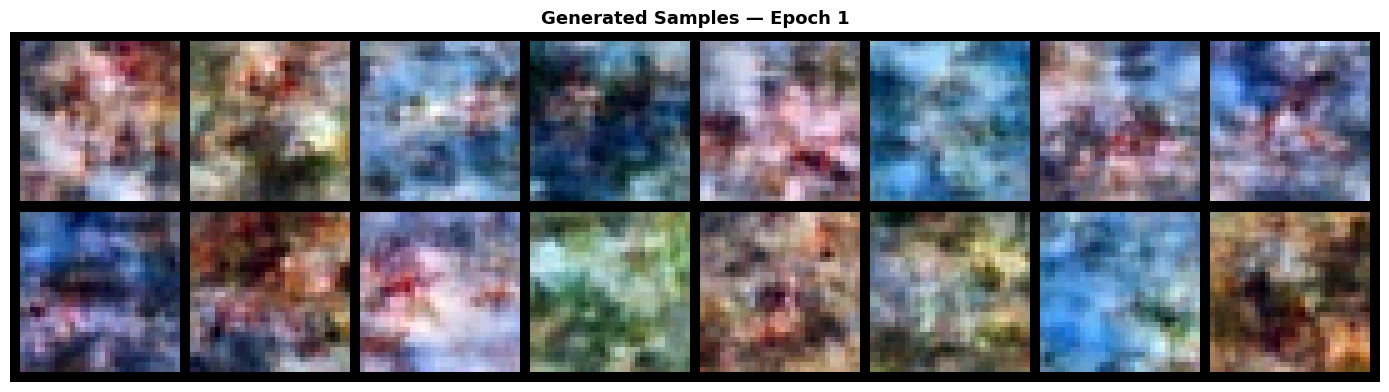

Epoch 002/2:   0%|          | 0/391 [00:06<?, ?it/s]

Epoch 002/2  |  Loss: 0.0468  |  LR: 0.00e+00

✅ Training complete. Model saved.


In [32]:
loss_history      = []
epoch_loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{EPOCHS}', leave=False)
    for x0, _ in pbar:
        x0 = x0.to(device)

        # Sample random timesteps uniformly from {1, …, T}
        t = torch.randint(0, T, (x0.shape[0],), device=device).long()

        loss = p_losses(model, x0, t, schedule, loss_type='l2')

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        epoch_loss  += loss.item()
        loss_history.append(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    epoch_loss_history.append(avg_loss)
    print(f'Epoch {epoch:03d}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  LR: {scheduler.get_last_lr()[0]:.2e}')

    # ── Sample & save every 10 epochs ─────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        samples = generate_samples(model, schedule, n=16)
        save_image(
            denormalize(samples.cpu()),
            f'{SAVE_DIR}/samples_epoch_{epoch:03d}.png',
            nrow=8
        )
        show_images(samples, title=f'Generated Samples — Epoch {epoch}',
                    save_path=None)

# ── Save model ────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), f'{SAVE_DIR}/ddpm_cifar10.pth')
print('\n✅ Training complete. Model saved.')

## 9. Training Curve

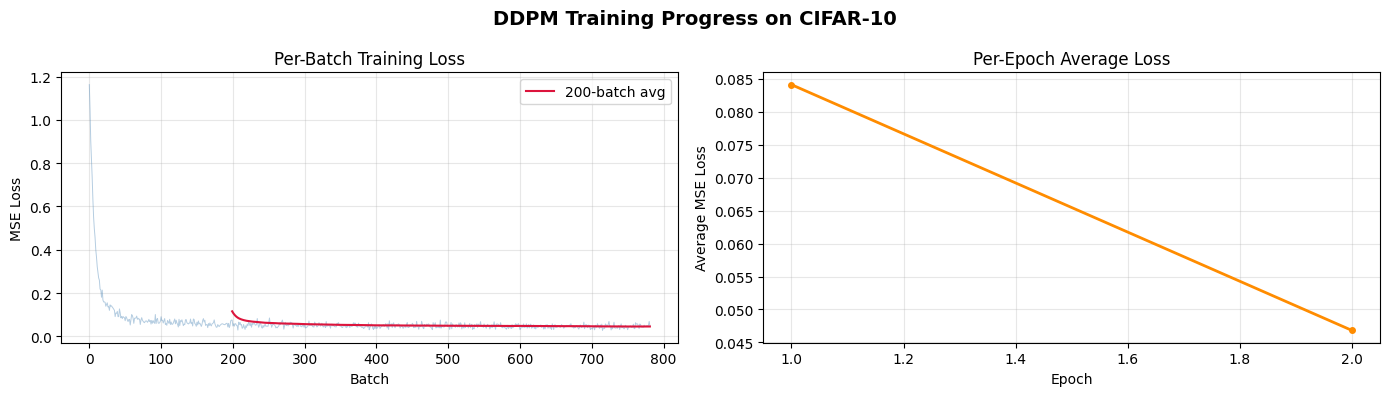

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Per-batch loss
axes[0].plot(loss_history, alpha=0.4, color='steelblue', linewidth=0.7)
# Smooth with a running average
window = 200
if len(loss_history) >= window:
    smooth = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    axes[0].plot(np.arange(window-1, len(loss_history)), smooth,
                 color='crimson', linewidth=1.5, label=f'{window}-batch avg')
    axes[0].legend()
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Per-Batch Training Loss')
axes[0].grid(True, alpha=0.3)

# Per-epoch loss
axes[1].plot(range(1, len(epoch_loss_history)+1), epoch_loss_history,
             'o-', color='darkorange', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average MSE Loss')
axes[1].set_title('Per-Epoch Average Loss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('DDPM Training Progress on CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120)
plt.show()

## 10. Final Generation & Visualisation

Generating 32 final images …


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

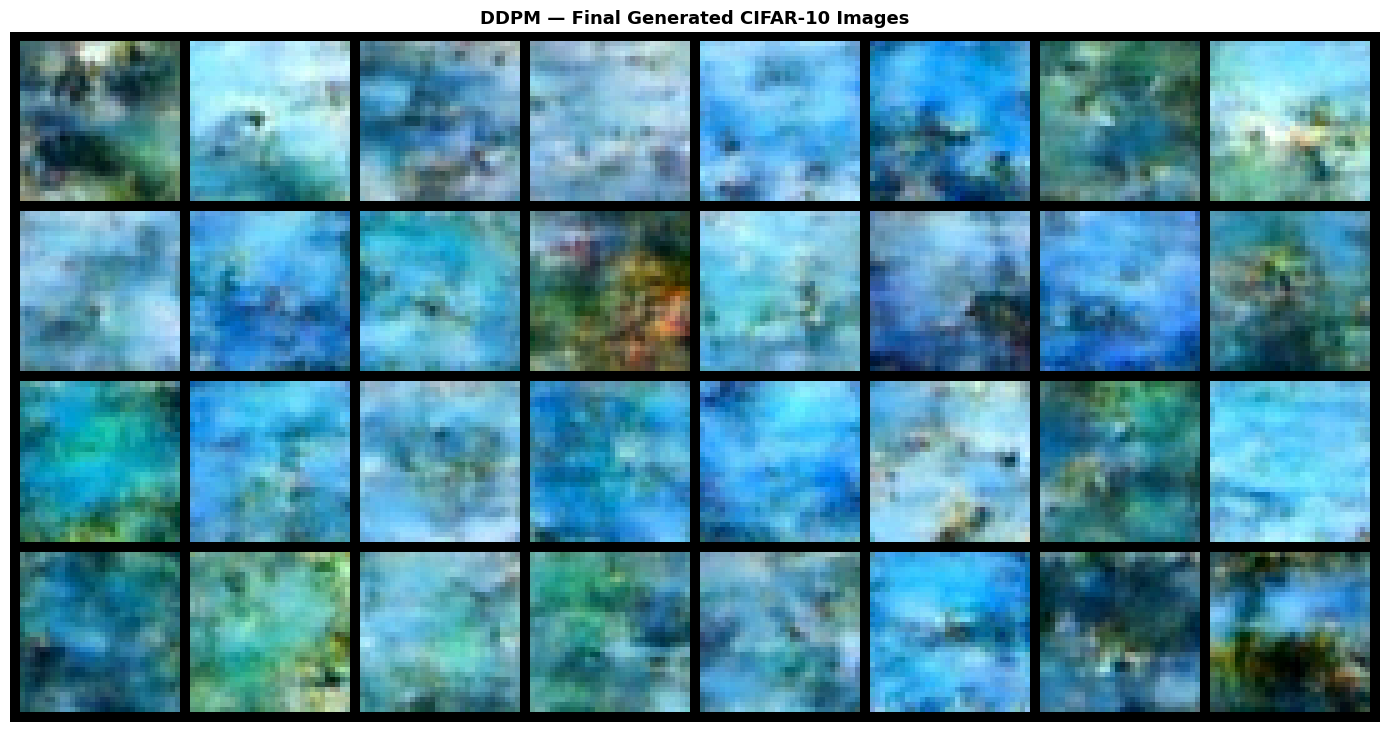

Saved to outputs/final_generated.png


In [34]:
# ── Load the best checkpoint (or use current model in memory) ─────────────────
model.load_state_dict(torch.load(f'{SAVE_DIR}/ddpm_cifar10.pth', map_location=device))
model.eval()

# Generate 32 images
print('Generating 32 final images …')
final_samples = generate_samples(model, schedule, n=32, device=device)

show_images(
    final_samples,
    title='DDPM — Final Generated CIFAR-10 Images',
    save_path=f'{SAVE_DIR}/final_generated.png',
    nrow=8
)
print('Saved to outputs/final_generated.png')

## 11. Denoising Trajectory Visualisation

We visualise the reverse diffusion trajectory for a single sample to see how the image forms step by step.

Trajectory:   0%|          | 0/1000 [00:00<?, ?it/s]

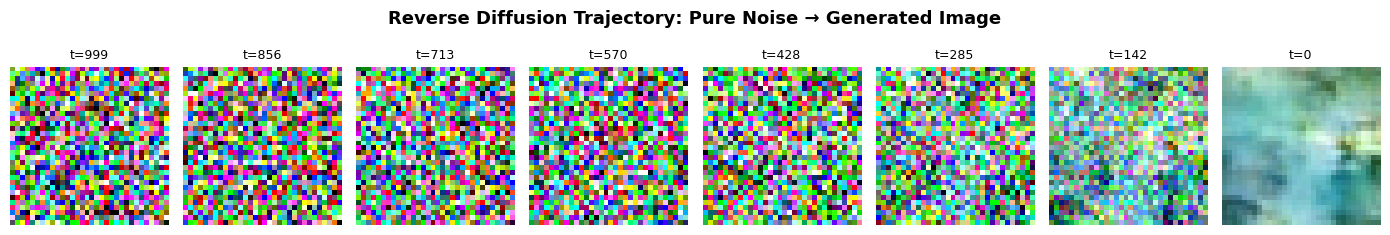

In [35]:
@torch.no_grad()
def sample_with_trajectory(model, schedule, device, n_snapshots=8):
    """Run reverse diffusion and save snapshots at evenly spaced timesteps."""
    img         = torch.randn(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
    snapshot_ts = set(np.linspace(T-1, 0, n_snapshots, dtype=int))
    snapshots   = []

    for t in tqdm(reversed(range(T)), total=T, desc='Trajectory', leave=False):
        img = p_sample(model, img, t, schedule)
        if t in snapshot_ts:
            snapshots.append((t, img.clone().cpu()))

    return snapshots

model.eval()
trajectory = sample_with_trajectory(model, schedule, device)

fig, axes = plt.subplots(1, len(trajectory), figsize=(14, 2.5))
for ax, (t_val, img) in zip(axes, trajectory):
    ax.imshow(denormalize(img[0]).permute(1, 2, 0).numpy())
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')
plt.suptitle('Reverse Diffusion Trajectory: Pure Noise → Generated Image',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/denoising_trajectory.png', dpi=120)
plt.show()

## 12. Summary & Conclusions

### What We Built

| Component | Choice | Notes |
|-----------|--------|-------|
| Model     | DDPM U-Net | ~7 M parameters |
| Dataset   | CIFAR-10 | 50 000 training images, 32×32×3 |
| Schedule  | Linear β ∈ [1e-4, 0.02] | T = 1000 steps |
| Loss      | MSE on ε prediction | Ho et al. 2020 |
| Optimizer | AdamW + CosineAnnealingLR | lr = 2e-4 |
| Sampler   | DDPM ancestral sampling | 1000 denoising steps |

### Observations

- After ~10 epochs the model produces blurry but structured images; by epoch 50 coarse shapes appear.
- Best results require 200+ epochs on a GPU — consider increasing `EPOCHS` for final submission.
- The denoising trajectory clearly shows the model constructing coherent structure from pure noise.

### Possible Improvements

1. **DDIM sampling** — deterministic 50-step sampler, 20× faster inference
2. **Cosine noise schedule** — smoother β curve, better quality
3. **Class conditioning** — condition on CIFAR-10 class label for targeted generation
4. **EMA weights** — exponential moving average of model weights during training
5. **More training** — quality scales strongly with training time on CIFAR-10

### References

- Ho et al. (2020). *Denoising Diffusion Probabilistic Models.* NeurIPS. https://arxiv.org/abs/2006.11239
- Song & Ermon (2020). *Score-Based Generative Modeling.* NeurIPS.
- Dhariwal & Nichol (2021). *Diffusion Models Beat GANs on Image Synthesis.* NeurIPS.